# Classification des textes :: Vue d'ensemble

## Objectif 

Nous allons construire un détecteur de spam qui apprend à marquer les nouveaux courriels non vus comme spam ou non spam.

On va montrer au détecteur des **exemples de courriels de spam** (par exemple, signalés par les utilisateurs) et **d'exemples de courriels normaux** (non spam). 

Nous travaillons donc avec un exemple **d'apprentissage supervisé**.

## Données

Nous utiliserons le corpus d'emails publics de [SpamAssassin] (https://spamassassin.apache.org/).   
Cet ensemble de données contient ~6'000 emails étiquetés dont ~30% sont des spams.  
Si vous souhaitez en savoir plus sur cet ensemble de données, consultez [ce lien](https://spamassassin.apache.org/old/publiccorpus/).  
(*Note : les ensembles de données de texte sont appelés corpus et les échantillons sont appelés documents.*) 

L'ensemble de données a été téléchargé pour vous et est disponible dans le dossier *data*.

## Aperçu du Notebook

* **Charger les données**
* **Prétraitement du texte**
* **Exploration des données** 
* **Extraction de caractéristiques** 
* **Construire un détecteur de spam** 
* **Qu'a appris notre modèle ? Analyse des erreurs** 

# Classification des textes  :: Détection de spam


## Charger les données

In [1]:
# Load libraries and helper functions
import tools

In [2]:
# Load the data
df = tools.load_data()

Data loaded.
Data size: (5832, 2)


Vérifions le nombre d'échantillons par classe dans les données.

Samples per class (%):
non-spam    70.3
spam        29.7
Name: proportion, dtype: float64




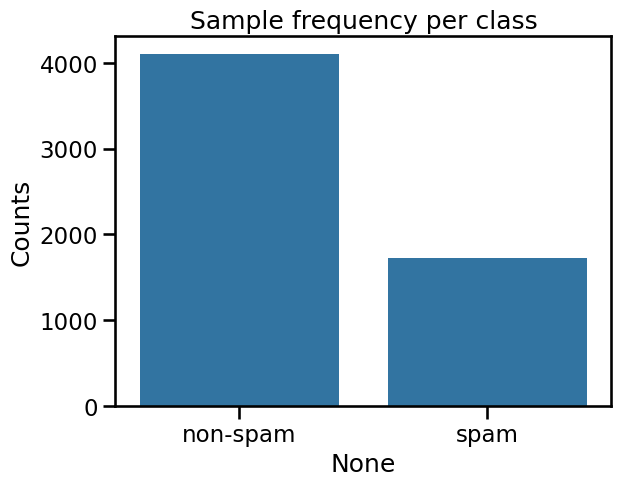

In [3]:
tools.plot_class_frequency(df)

Maintenant, regardons quelques lignes de l'ensemble de données.

**Note** : L'étiquette est 0 pour le non-spam et 1 pour le _spam_.

In [4]:
# If you rerun this cell then you get a different set of samples displayed
df.sample(3)

,label,text
3273,0,"cwg-dated-1033065967.2dc492@DeepEddy.Com said: > From: Chris Garrigues <cwg-exmh@DeepEddy.Com> > Date: Wed, 28 Aug 2002 11:07:01 -0500 > > Here's a fix that I think will make a real difference. > > Ftoc_ShowSequences needs to be able to be called with an optional > list of msgids > to update and if it's called that way it only removes or adds tags > for those > messages. Then in places like MsgChange, we only update the > messages which have > changed. > > Also, a separate Ftoc_ShowSequence function which only updates the > display of > one sequence should be written which also takes an optional list of > msgids. > > In a place like MsgChange, it would only need to update the cur > sequence. > > If nobody else gets to it, I'll do this when I get back. > I just checked this in. Let me know if it helps. > Chris Congratulations Chris, you just made the hall of fame!! Speed is much better now. I haven't done any tests, but I'd say that latency dropped 2-3 times and we're back in good shape again. Well done! /Anders _______________________________________________ Exmh-workers mailing list Exmh-workers@redhat.com https://listman.redhat.com/mailman/listinfo/exmh-workers"
1207,1,"<html><body> <table bgcolor=3D""663399"" border=3D""2"" width=3D""999"" cellspacing=3D""0"" cel= lpadding=3D""0""> <tr> <td colspan=3D""3"" width=3D""999""> <hr><font color=3D#66FF66""> <font size=3D""5""><center> We <b>won't</b> lie to you, smaller <b>IS</b> better.......<br> .<br> .<br> .<br> .<br> .<br> .<br> .<br> .<br> When you're talking about <b>SUPERCOMPUTERS!</b><br><br><br> We HATE to break it to you guys, <br>but women don't think that way... <center><b><br><br> In the REAL WORLD, <br> Size <font size=3D""7""><i>DOES </i><font size=3D""6"">matter. <font size=3D""7= "">BIG <font size=3D""6""> time!<br><br> <table bgcolor=3D""#CCFF33"" border=3D""2"" width=3D""600""> <tr> <td><center> <center><font size=3D""6""> <a href=3D""http://www.freehostchina.com/site2/web2pleasure/index.html""> <b= r><b>Breakthroughs</a> in Science</b><br> have finally <i>enabled</i> men like you,<br> to take things into their o= wn hands! <br> <br> </td></tr></table> <br> <font size=3D""5""> Most of our techniques are 21st Century, but some of these techniques <br>= have been around for CENTURIES! <br> <br> <i>Ancient secrets</i>, that only specific tribes, taught their wisest eld= ers.<br> <br> We reveal ALL of these to you, and<a href=3D""http://www.freehostchina.com/= site2/web2pleasure/index.html""> more!</a><br> <br> <br> <font color=3D""#66CCFF""> What can our techniques help you accomplish <i>naturally</i>?<br> <br> <font size=3D""6""> <font color=3D""#FFFF00"" > Effectively ADD between 1"" to 4.5"" to your penis size! <br> <font size=3D""4""> <i>Without</i> surgery, pumps, or other painful methods. <br><br> <table bgcolor=3D""#CCFF33"" border=3D""2"" width=3D""600""> <tr> <td><center> <font color=3D""#6633FF""><font size=3D""5""><br> ""I'm convinced, let me get access to these,<br> <a href=3D""http://www.freehostchina.com/site2/web2pleasure/index.html""> AM= AZING TECHNIQUES ONLINE!</a>"" <br> <br> </td></tr></table> <br> <font color=3D#66FF66""> <font size=3D""5""><br> Every man on the <i>planet</i> would like to increase <br> his pen..."
3700,0,"Not exactly new bits, but I enjoyed seeing The Economist pick up on the similarity between computer and social networks: http://www.economist.com/science/displayStory.cfm?story_id=1365118 _________________________________________________________________ Chat with friends online, try MSN Messenger: http://messenger.msn.com"


## Prétraitement du texte

Un bon prétraitement de texte est une partie essentielle de tout projet NLP !

Notre objectif ici est de construire un modèle qui distingue le non-spam du spam.   
L'idée ici est de "nettoyer" et de "normaliser" le texte brut avant de le soumettre à notre modèle d'apprentissage automatique.   
Nous devons conserver autant de mots "informatifs" que possible, tout en éliminant les mots "uniformes". L'élimination du contenu inutile, c'est-à-dire le "bruit", de nos textes contribuera à améliorer la précision de nos modèles.

<div class="alert alert-success">
<h3>Questions</h3>
    
Prenez quelques minutes pour regarder le texte brut.  
    
__Q1.__ Quelles sont, selon vous, les parties du texte qui devraient être supprimées pour le rendre lisible ?
    
__Q2.__ Comment les parties que nous venons d'enlever pour nettoyer le texte, peuvent-elles encore être utiles pour distinguer le spam du non-spam ?
</div>

### Vos réponses

__Q1.__ 
* Balises HTML 
* URL
* Adresses électroniques
* Les signes de ponctuation, les chiffres (par exemple 2002, 1.1, ...)
* Espaces blancs multiples
* Conversion des majuscules et des minuscules (par exemple, Dog vs dog, ...)
* MOTS D'ARRÊT anglais (par exemple, a, is, my, i, all, and, by...)
* ...


__Q2.__ Le texte explicite à l'intérieur des balises HTML, des URL ou des adresses électroniques sera tellement différent entre nos échantillons qu'il est peu probable qu'il soit utile pour distinguer les spams des non-spams.  
Cependant, le nombre d'occurrences des balises HTML, des URL, etc. dans un texte pourrait être utile pour cette distinction. De même, la longueur des courriels et la fréquence des signes de ponctuation ou des majuscules peuvent également nous donner des indices pour savoir si nous avons affaire à du spam ou non.    

La fonction *clean_corpus* ci-dessous prendra en charge les parties soulevées par la Question 1.

Pour les idées de la question 2, nous créerons de nouvelles fonctionnalités et étudierons leurs effets dans la sous-section  **What about "spammish" signatures?**. 

In [5]:
df = tools.clean_corpus(df)

print("Data cleaned")

Data cleaned


Voyons quelques exemples "nettoyés".

In [6]:
tools.show_clean_text(df)


Original document:

-----BEGIN PGP SIGNED MESSAGE----- Hash: SHA1 On Tuesday 27 August 2002 07:45 am, Justin Mason
wrote: > Tony Svanstrom, on SpamAssassin-talk, noted this US patent: > >
http://appft1.uspto.gov/netacgi/nph-Parser?Sect1=PTO2&Sect2=HITOFF&u=/netah >tml/PTO/search-
adv.html&r=62&f=G&l=50&d=PG01&s1=spam&p=2&OS=haiku&RS=spam > > Method of anti-spam > > Abstract > >
A method of anti-spam is to set an optional trustcode, or a trustlist, or > at least a trustweb
based on online mail delivery at a recipient's e-mail > address. A mail sender is compelled at the
first time to deliver a mail > by way of: taking the way of "Visiting trustweb and sending online",
or > enclosing the recipient's trustcode in the mail and sending in another way > other than the
mentioned. After the sender's e-mail address has been stored > automatically in the recipient's
trustlist, the sender may send mails to > the same recipient in whatever the ways feasible. > > >
Sounds a lot like TMDA to me. :(

## Exploration des données : : Comment les spams se distinguent-ils ?

### Mots fréquents

Quels mots distinguent le spam du non-spam ? Peut-on identifier les mots d'un texte qui sont les plus informatifs sur son sujet ?

Trouvons les 10 mots les plus fréquents dans le spam et le non-spam et comparons-les.

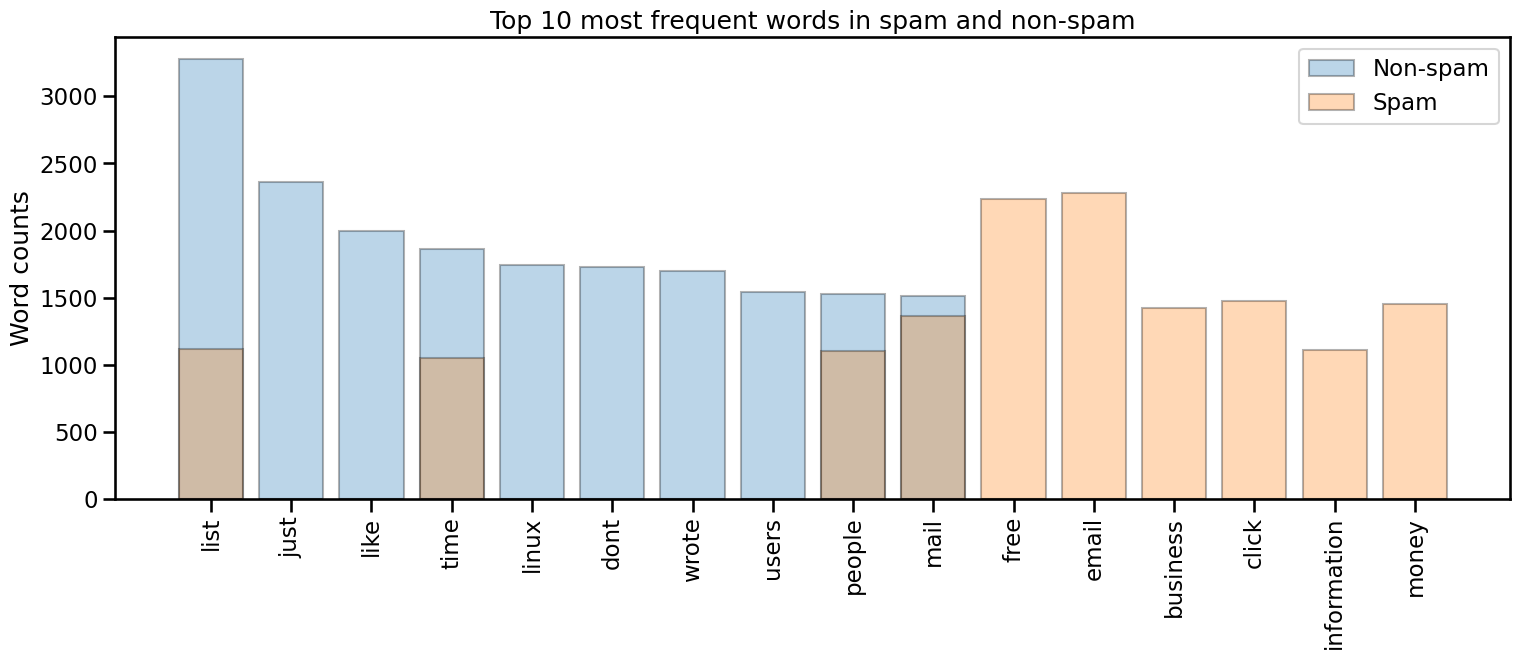

In [7]:
tools.plot_most_common_words(df=df, N=10)

<div class="alert alert-success">
<h3>Questions</h3>
    
Q1.__ Parmi les 10 mots "spammish" les plus fréquents, lesquels sont propres à cette classe ?

Q2.__ Lesquels des 10 mots "non spammish" les plus fréquents sont uniques à cette classe ?
     
Q3.__ Parmi les mots qui apparaissent dans les deux listes, lesquels sont probablement encore utiles pour distinguer les classes ?
    
Q4.__ Lesquels ne le sont probablement pas ?
    
    
</div>

### Vos réponses

__Q1.__ **Les 10 mots "spammées" les plus fréquents**: 

* free
* email
* click
* business
* money

__Q2.__ **Les 10 mots non-"spammées" les plus fréquents**:
* just
* like
* linux
* wrote
* users  

__Q3.__ **Présente dans les deux listes mais pourrait être utile pour les distinctions**:
* list
* time

__Q4.__ **Présente dans les deux listes mais peu susceptibles d'être utiles**:
* people
* mail

### Exploration 1


<div class="alert alert-success">
    
Changez `N=10` en `N=30` et comparez le résultat.
</div>

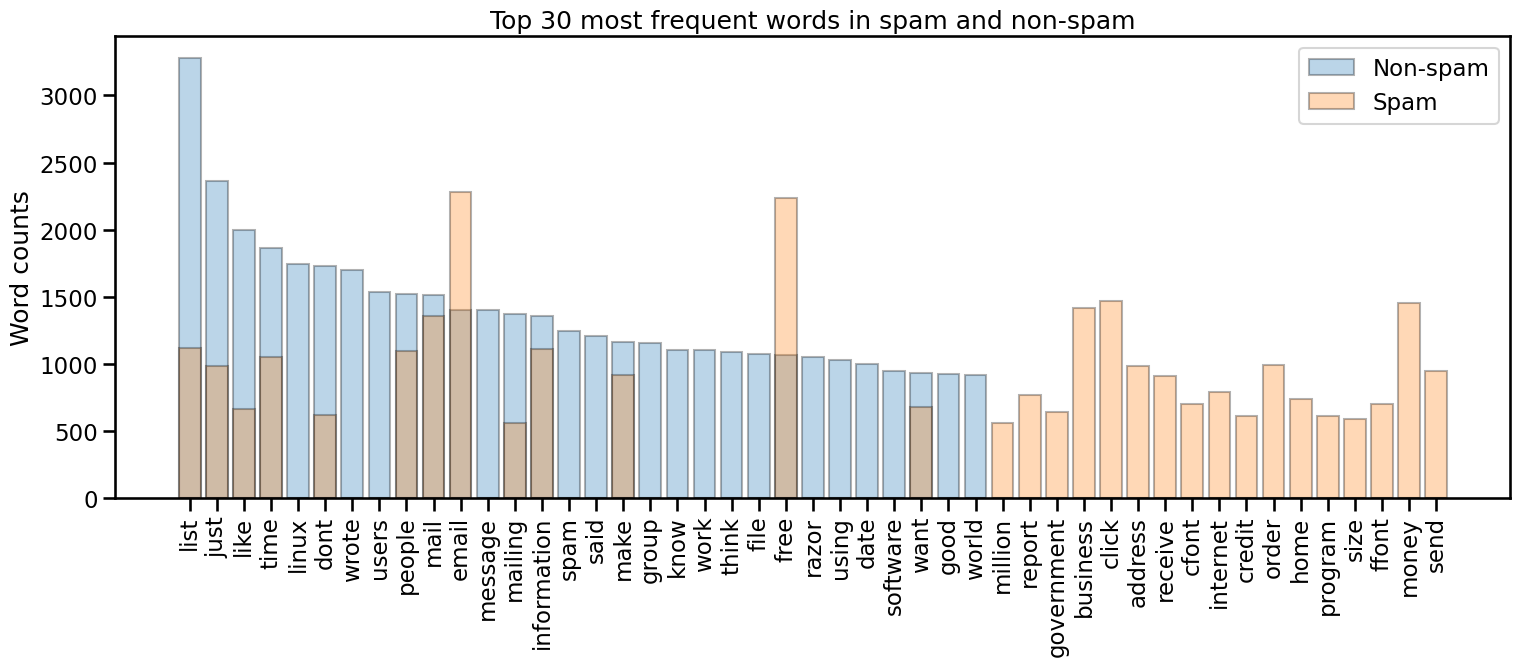

In [8]:
tools.plot_most_common_words(df=df, N=30)

### Vos observations

Plus nous utilisons de mots-clés, plus nous obtenons de chevauchements entre les classes.  
Cependant, des mots comme _email_ ou _free_ sont toujours beaucoup plus fréquents dans la classe **spam**. 

### Que peut-on dire des indicateurs ou signatures de "spam" ? ?

* Les spams contiennent-ils plus de balises HTML ? 
* Les non-spams contiennent-ils plus d'URL et d'adresses e-mail ? 
* Les spams sont-ils plus longs que les non-spams ? 
* ...

C'est ce que nous allons découvrir !

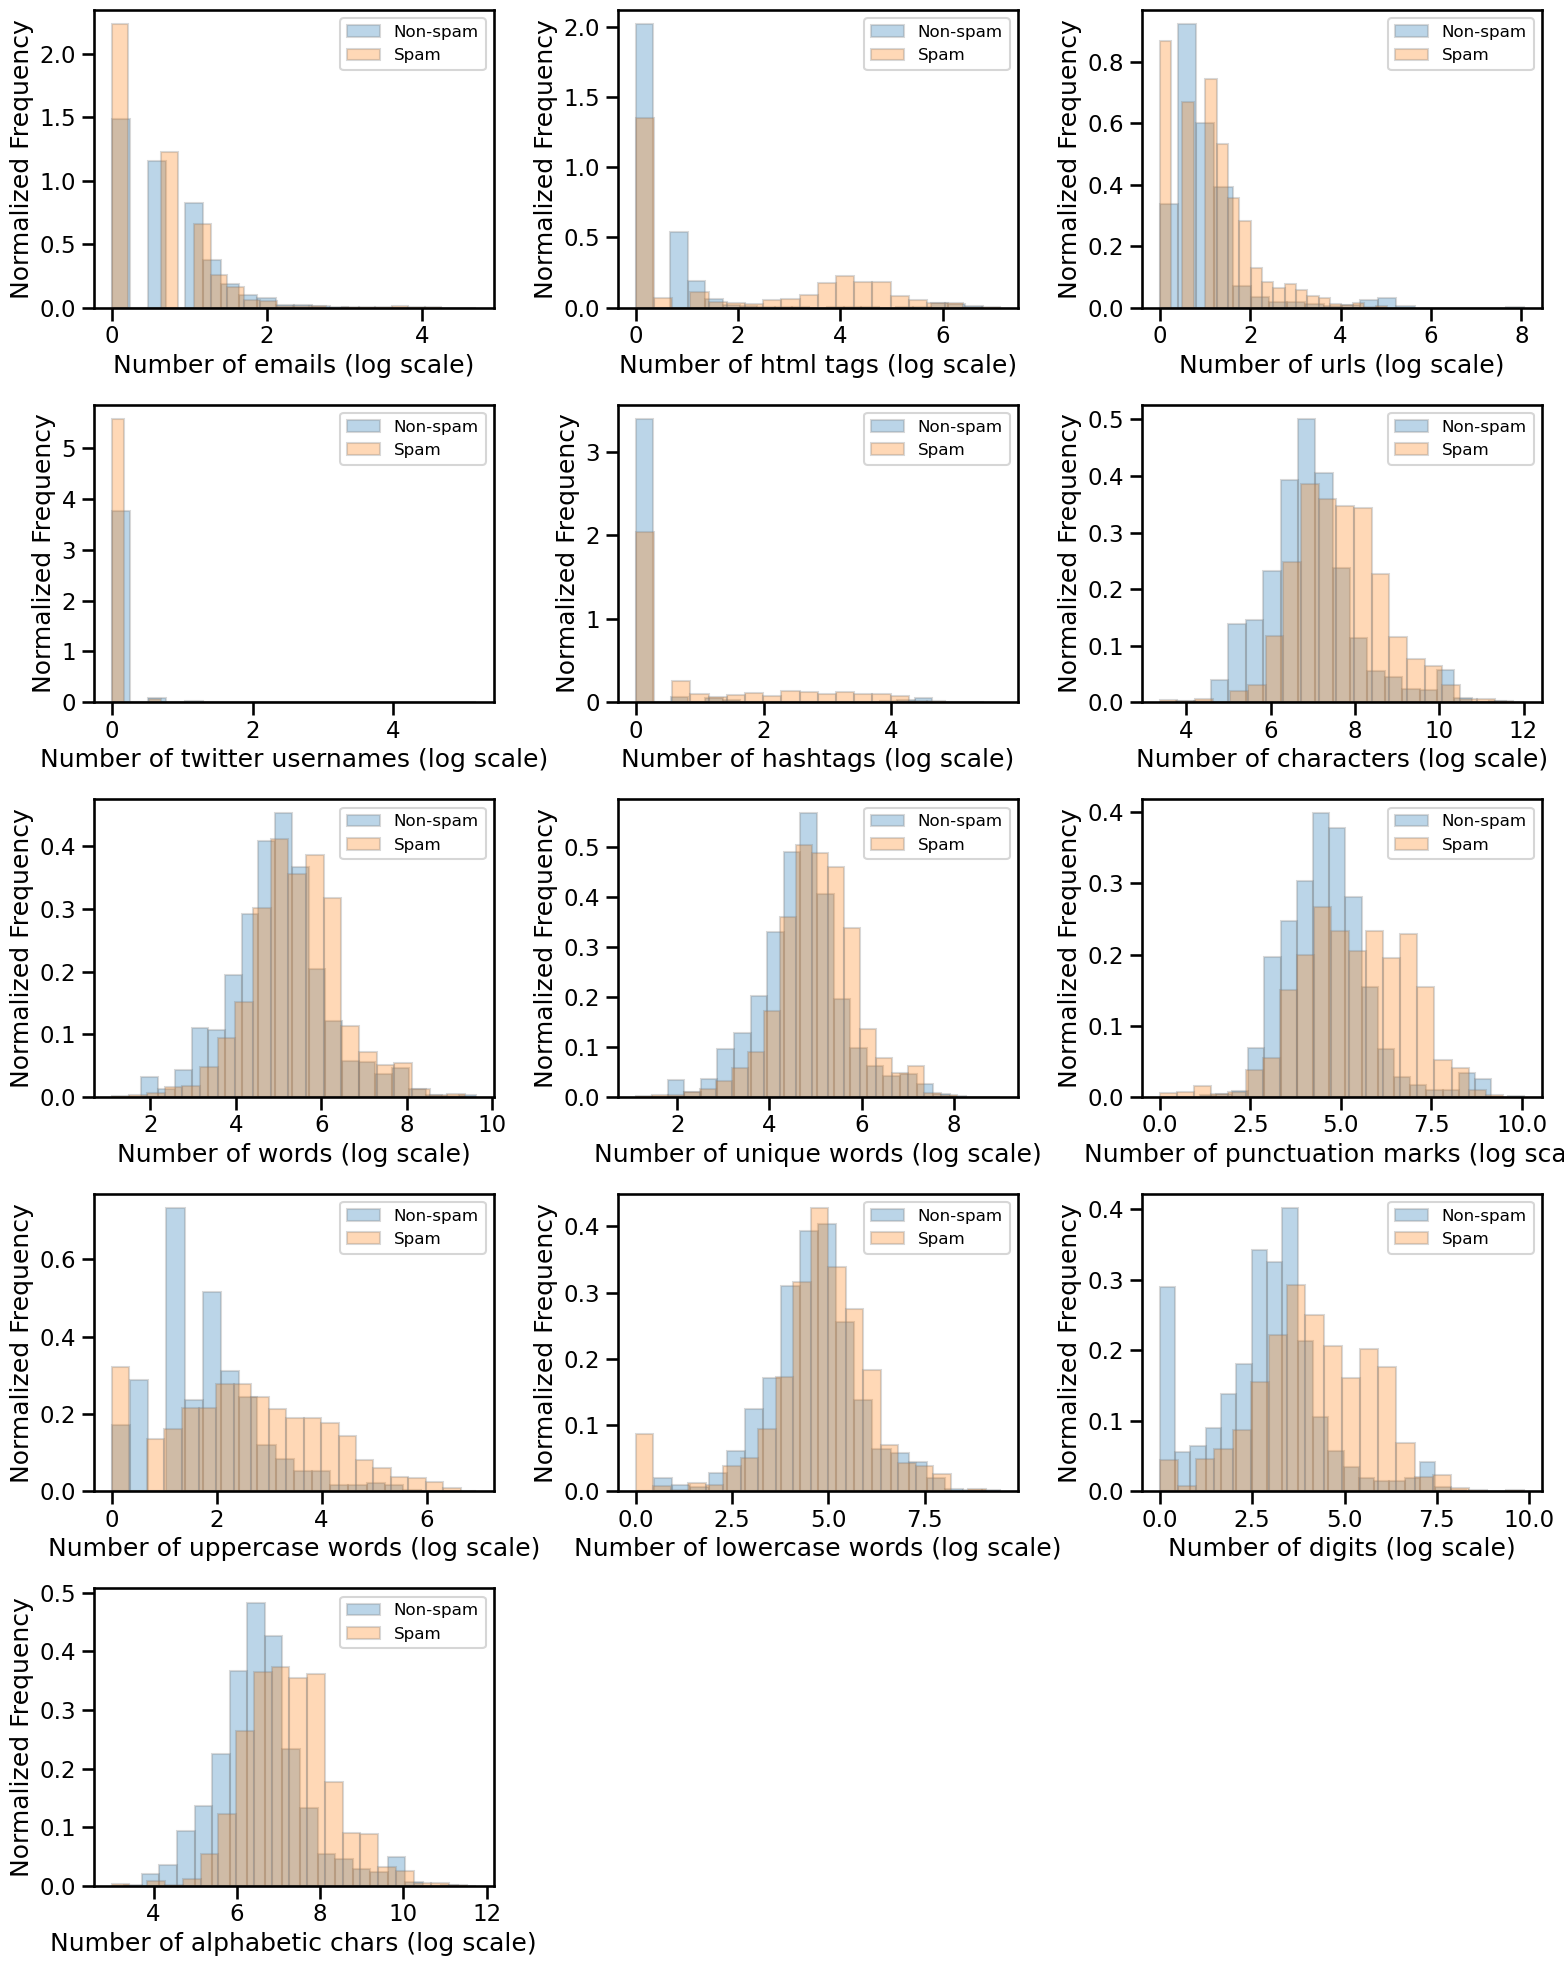

In [9]:
features = tools.get_features(df=df)

## Extraction de caractéristiques

Les ordinateurs ne comprennent pas le langage naturel. Alors, comment représenter le texte ?

L'un des modèles les plus simples mais efficaces et couramment utilisés pour représenter le texte pour l'apprentissage automatique est le modèle ***Bag of Words*** ([documentation en ligne](https://en.wikipedia.org/wiki/Bag-of-words_model)). Lorsqu'on utilise ce modèle, on écarte la majeure partie de la structure du texte d'entrée (ordre des mots, chapitres, paragraphes, phrases et mise en forme) et on ne compte que la fréquence d'apparition de chaque mot dans chaque texte. Le fait d'écarter la structure et de ne compter que les occurrences des mots conduit à l'image mentale de la représentation du texte comme un "sac".  

**Exemple:** Soit notre corpus jouet contenant quatre documents.

$ corpus = ['I\;enjoy\;paragliding.',  $  
$\hspace{2cm}'I\;like\;NLP.',$  
$\hspace{2cm}'I\;like\;deep\;learning.',$  
$\hspace{2cm}'O\;Captain!\;my\;Captain!']$ 

In [10]:
tools.show_bag_of_words_vector()

,captain,deep,enjoy,i,learning,like,my,nlp,o,paragliding
Text,,,,,,,,,,
I enjoy paragliding.,0,0,1,1,0,0,0,0,0,1
I like NLP.,0,0,0,1,0,1,0,1,0,0
I like deep learning.,0,1,0,1,1,1,0,0,0,0
O Captain! my Captain!,2,0,0,0,0,0,1,0,1,0


Bag of Words a converti tous les documents en vecteurs numériques. Chaque colonne représente un mot du corpus et chaque ligne un des quatre documents. La valeur dans chaque cellule représente le nombre de fois que ce mot apparaît dans un document spécifique. Par exemple, dans le quatrième document, le mot `capitain` apparaît deux fois et les mots `my` et `O` apparaissent une fois.

## Construisons notre détecteur de spam

(Dans la section précédente, nous avons vu comment effectuer le prétraitement du texte et l'extraction de caractéristiques du texte.)  
Nous sommes maintenant prêts à construire notre modèle d'apprentissage automatique pour détecter les spams.  
Nous allons utiliser un **simple classificateur de régression logistique** ([documentation en ligne](https://en.wikipedia.org/wiki/Logistic_regression)).

Tout d'abord, nous divisons les données en deux ensembles : l'ensemble `train` et l'ensemble `test`. Rappelez-vous:
- Nous utiliserons l'ensemble `train` pour adapter notre modèle.  
- **Notez que nous n'avons pas créé d'ensemble de données de validation**. En fait, nous allons utiliser la **validation croisée (5-fold)**. Ainsi, les ensembles de validation sont **automatiquement créés en interne**.  
- L'ensemble de `test` sera utilisé pour évaluer la performance de notre modèle. 

### Ligne de base

70.3% des échantillons sont des non-spams.   
**Ce modèle de base naïf atteindrait 70+% en faisant très peu.**

### Classification des spams

<Axes: title={'center': 'Confusion matrix'}, xlabel='Predicted label', ylabel='True label'>

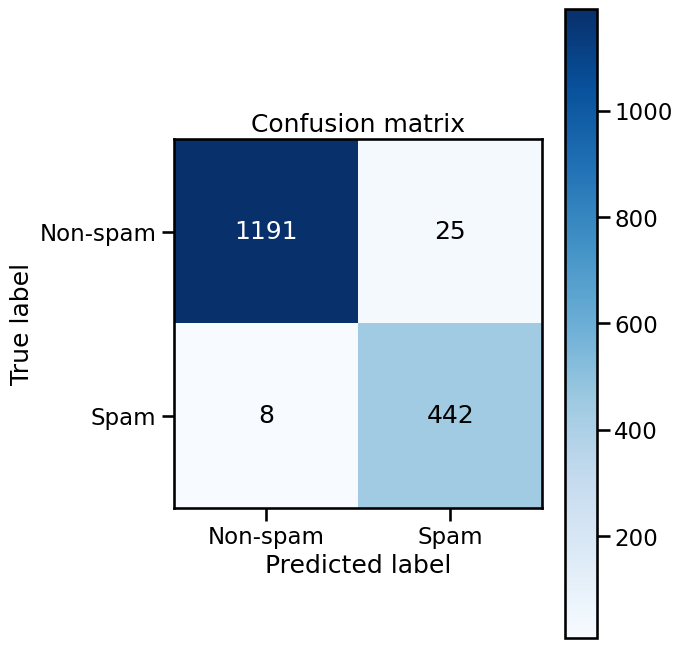

In [11]:
# Train/test splitting
df_train, df_test = tools.train_test_split_(df)

# Fit model on the train data
model = tools.fit_model(df_train)

# Print predictions on test set
tools.plot_confusion_matrix(df_test, model)

**Confusion matrices**  

Les matrices de confusion sont un bon moyen d'évaluer les performances des modèles de classification.  
Les rangées (rows) correspondent aux vraies classes et les colonnes aux classes prédites.  
Les entrées sur la diagonale principale de la matrice de confusion correspondent aux prédictions correctes tandis que les autres cellules nous indiquent le nombre d'erreurs de notre modèle ([documentation en ligne]((https://en.wikipedia.org/wiki/Confusion_matrix))).

* La première ligne représente les courriers non spam :  
On voit **1'187 ont été correctement classés comme 'non-spam'**,  
tandis que **29 (~2,3%) ont été mal classés comme 'spam'**.
* La deuxième ligne représente les messages de spam :  
On voit **437 ont été correctement classés comme 'spam'**,  
tandis que **13 (~2,8%) ont été mal classés comme 'non-spam'**.

Notre modèle s'est bien comporté !

### Qu'est-ce que notre modèle a appris des données?

Notre modèle de régression logistique a appris **quels mots sont les plus indicatifs** de non-spam et quels mots sont les plus indicatifs de spam.  
* **Les coefficients positifs sur la droite** correspondent aux mots qui, _selon le modèle_, **sont indicatifs de spam**.  
* **Les coefficients négatifs à gauche** correspondent à des mots qui, _selon le modèle_, **sont indicatifs de non-spam**.

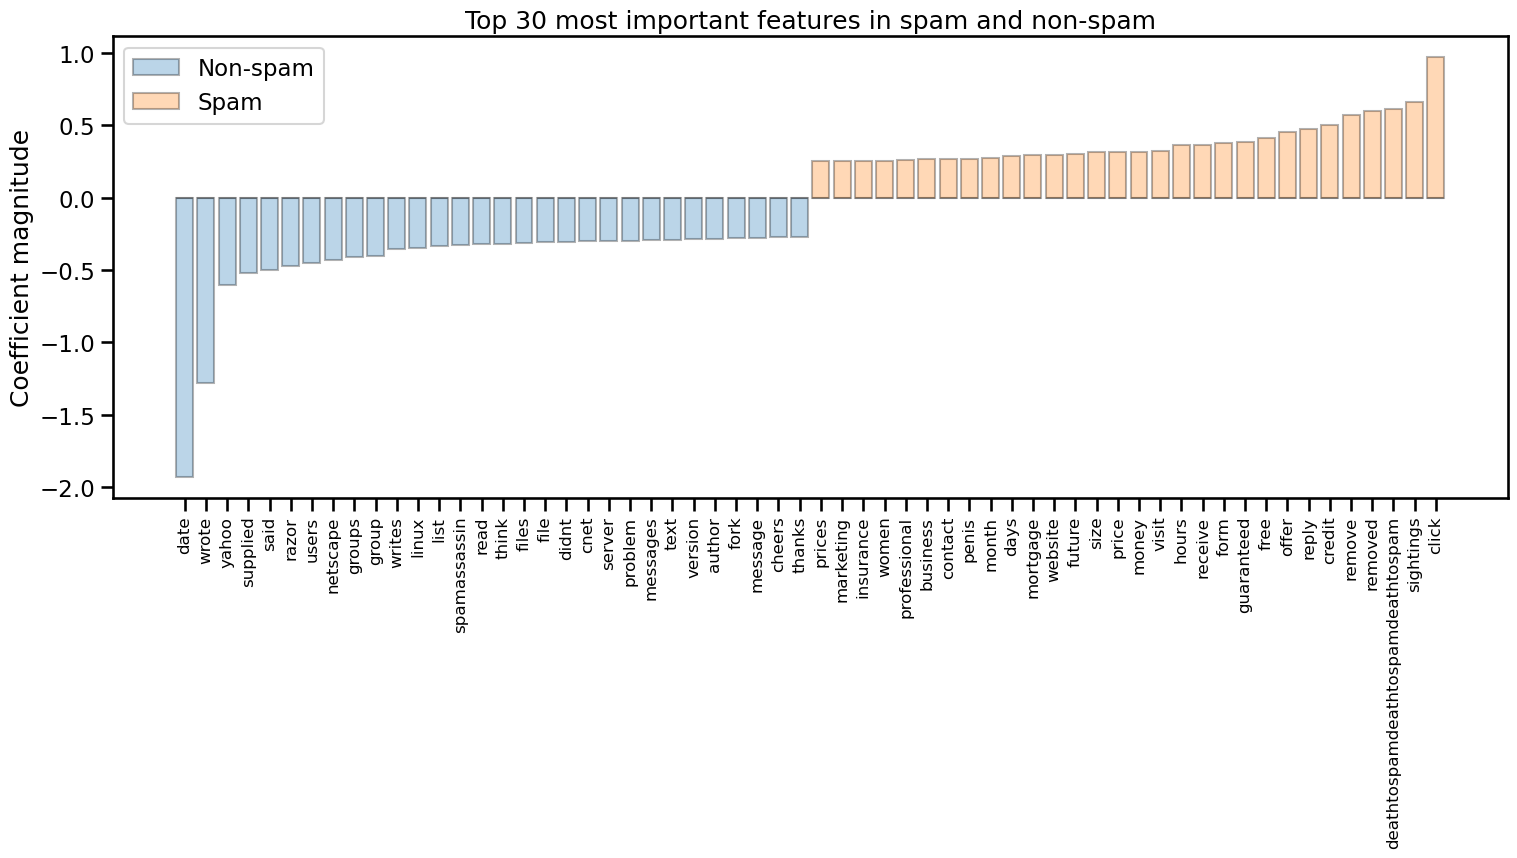

In [12]:
tools.visualize_coefficients(model, n_top_features=30)

<div class="alert alert-success">
<h3>Questions</h3>
    
__Q1.__ Selon le modèle, quels mots sont des indicateurs forts de non-spam, respectivement de spam ?  
    
__Q2.__ Se recoupent-ils avec les résultats de notre analyse ?    
</div>

### Vos réponses

Q1.

* Selon le modèle, des mots tels que "date", "wrote", "yahoo", "said", "linux", ... sont **des indicateurs forts de non-spam**.

* Des mots tels que "click", "credit", "remove", "free", "offer", "money" ... **indiquent un spam**.

Q2. En effet, certains le font. Par exemple, nous avions déjà identifié "wrote", "said" et "linux" comme des indicateurs potentiels de non-spam. De même, "click", "credit", "free", et "money" suggéraient le spam.


### Analyse des erreurs : : Où notre modèle échoue-t-il ?

Nous allons maintenant analyser les courriers mal classés pour mieux comprendre où le modèle n'a pas réussi à faire des prédictions correctes.

Document index: 16 


Original Text
Dear Reader, How has Veuve Clicquot's sponsorship become so successful? Naomi Hancock,= =20 UK PR
Manager, tells us all about it in an exclusive interview. Also read= =20 about the launch of
SponsorRating, the first sponsorship rating agency,=20 our unsual transactions of the month, and a
"special X-treme" Sponsorship= =20 Alert. As this is the last issue for the summer, we wish you a
good August and=20 will be back in September. Your comments are always welcome, so please email us
at=20 news@sponsorclick.com. All our best, Rachael Mark Editor In this issue: 1. Sponsorship, How
and Why? Veuve Clicquot Speaks=20 2. Press Release: SponsorClick Launches the First Sponsorship
Ratin= g=20 Agency 3. Unusual Transactions of the Month 4. Sponsorship Alert Special X-treme 5.
Special Offers: Taylor Nelson Sofr=E8s, BVA, Sport+Markt,=20 Mediametrie, and more 6. More Matching
Opportunities With SponsorClick 7. How to Contact SponsorClick? =20 =20
---------------

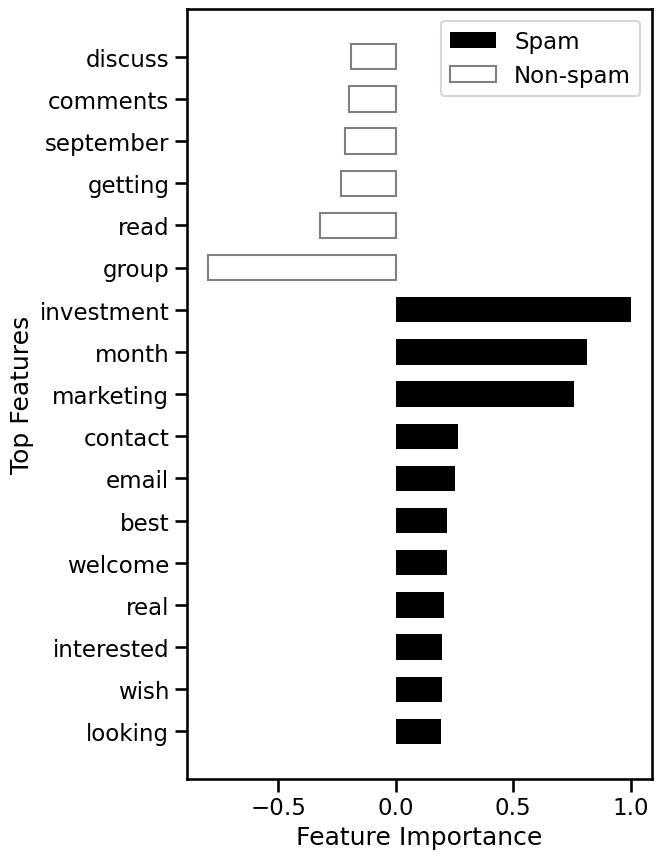

In [13]:
tools.error_analysis(df_test, model, doc_nbr=16)

### Exploration 2


<div class="alert alert-success">
    
Let's change the `doc_nbr`.
</div>

Document index: 10 


Original Text
<html> <head> <title>Buyers Alert Announce</title> </head> <body style="margin:8px 9px 9px 12px"
bgcolor="#ffffff" background="http://techupdate.zdnet.com/techupdate/i/bg_232850.gif" link="#003399"
alink="#cc0000" vlink="#666699"> <div align="center"> <a name="top"></a> <table width="624"
bgcolor="#232850" cellpadding="0" cellspacing="0" border="0"> <tr valign="bottom"><td
width="440"><img src="http://www.zdnet.com/graphics/newsletters/hd_buyers_alert.gif" width="440"
height="60" alt="ZDNet Announce"></td> <td width="184"><img
src="http://www.zdnet.com/graphics/newsletters/corner_anc.gif" width="184" height="8"></td></tr>
</table> <table width="624" bgcolor="#232850" cellpadding="0" cellspacing="0" border="0"> <tr
bgcolor="#ffffef"><td width="1" rowspan="2" bgcolor="#83A3CB"><img src="http://www.zdnet.com/b.gif"
width="1" height="1"></td> <td width="10" rowspan="2" bgcolor="#1E5C99"><img
src="http://www.zdnet.com/b.gif" width="10" height="1"></td> <t

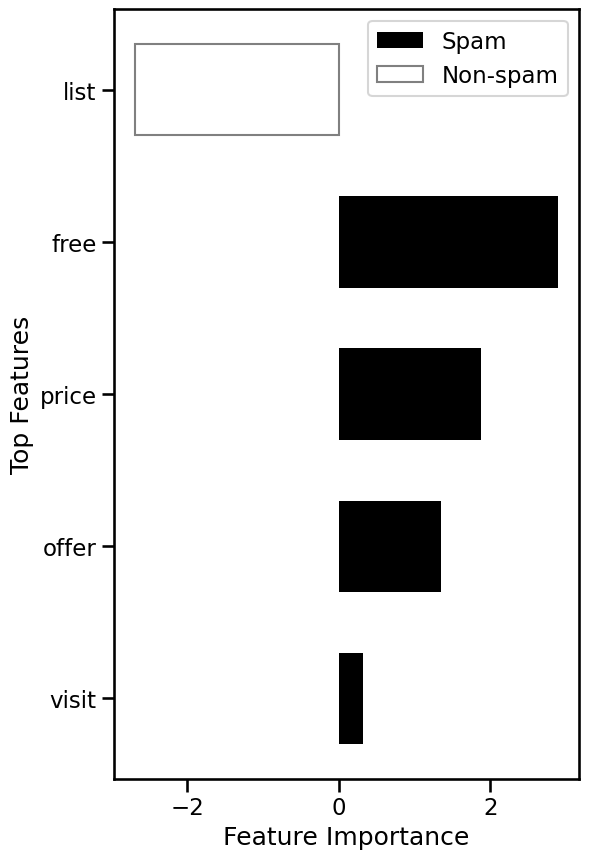

In [14]:
tools.error_analysis(df_test, model, doc_nbr=10)